In [2]:
# RailGuard Model Comparison

## YOLO11 vs YOLOv8 vs YOLO26

Comparison of binary railway-defect object detection models trained and evaluated using the RailGuard dataset.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

models = ["YOLO11", "YOLOv8", "YOLO26"]

# Confirmed validation metrics
validation = pd.DataFrame({
    "Model": models,
    "Precision": [0.444, 0.429, 0.43848],
    "Recall": [0.416, 0.378, 0.37209],
    "mAP50": [0.389, 0.355, 0.35514],
    "mAP50-95": [0.145, 0.129, 0.13254]
})

# Confirmed test metrics
testing = pd.DataFrame({
    "Model": models,
    "Precision": [0.477, 0.4316, 0.43436538499379523],
    "Recall": [0.406, 0.4258, 0.37617135207496655],
    "F1 Score": [0.439, 0.4287, 0.40317929267114194],
    "mAP50": [0.400, 0.3975, 0.3745384121914642],
    "mAP50-95": [0.144, 0.1372, 0.13632144707501986]
})

# YOLO26 F1 calculated from the confirmed test precision/recall
testing.loc[testing["Model"] == "YOLO26", "F1 Score"] = (
    2 * testing.loc[testing["Model"] == "YOLO26", "Precision"]
    * testing.loc[testing["Model"] == "YOLO26", "Recall"]
    / (
        testing.loc[testing["Model"] == "YOLO26", "Precision"]
        + testing.loc[testing["Model"] == "YOLO26", "Recall"]
    )
)

# YOLO11/YOLOv8 error-analysis counts are retained from the original notebook.
# YOLO26 was evaluated visually; individually classified TP/FP/FN counts
# were not produced, so they are intentionally left as NaN.
error_analysis = pd.DataFrame({
    "Model": models,
    "True Positives": [520, 463, np.nan],
    "False Positives": [485, 398, np.nan],
    "False Negatives": [974, 1031, np.nan]
})

display(validation)
display(testing)
display(error_analysis)


,Model,Precision,Recall,mAP50,mAP50-95
0,YOLO11,0.44400,0.41600,0.38900,0.14500
1,YOLOv8,0.42900,0.37800,0.35500,0.12900
2,YOLO26,0.43848,0.37209,0.35514,0.13254


,Model,Precision,Recall,F1 Score,mAP50,mAP50-95
0,YOLO11,0.477000,0.406000,0.439000,0.400000,0.144000
1,YOLOv8,0.431600,0.425800,0.428700,0.397500,0.137200
2,YOLO26,0.434365,0.376171,0.403179,0.374538,0.136321


,Model,True Positives,False Positives,False Negatives
0,YOLO11,520.0,485.0,974.0
1,YOLOv8,463.0,398.0,1031.0
2,YOLO26,NaN,NaN,NaN


## Validation Metrics Comparison

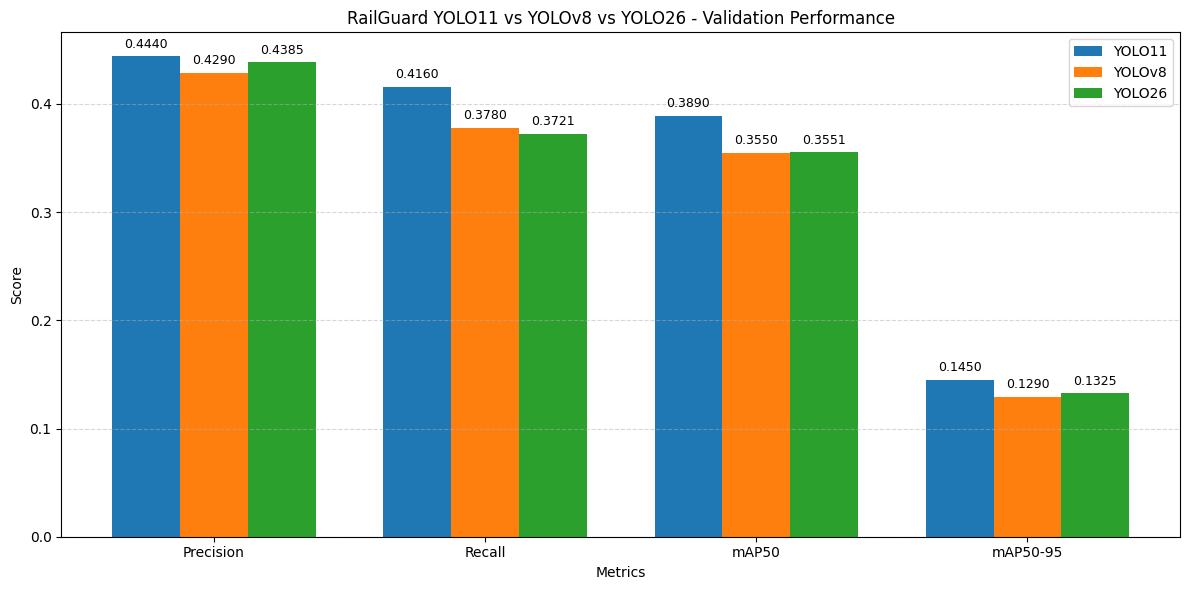

In [4]:
metric_names = ["Precision", "Recall", "mAP50", "mAP50-95"]

x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(12, 6))

for i, model in enumerate(models):
    values = validation.loc[
        validation["Model"] == model,
        metric_names
    ].values[0]

    bars = plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model
    )

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f"{value:.4f}",
            ha="center",
            fontsize=9
        )

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("RailGuard YOLO11 vs YOLOv8 vs YOLO26 - Validation Performance")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Testing Metrics Comparison

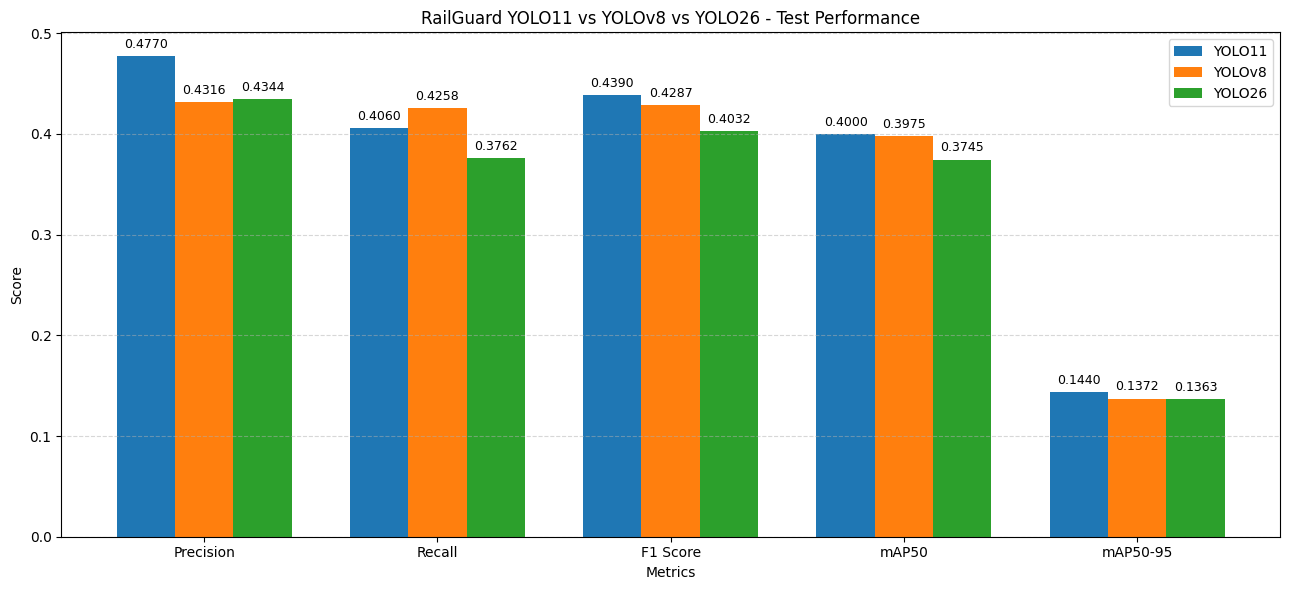

In [5]:
metric_names = [
    "Precision",
    "Recall",
    "F1 Score",
    "mAP50",
    "mAP50-95"
]

x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(13, 6))

for i, model in enumerate(models):
    values = testing.loc[
        testing["Model"] == model,
        metric_names
    ].values[0]

    bars = plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model
    )

    for bar, value in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f"{value:.4f}",
            ha="center",
            fontsize=9
        )

plt.xticks(x, metric_names)
plt.ylabel("Score")
plt.xlabel("Metrics")
plt.title("RailGuard YOLO11 vs YOLOv8 vs YOLO26 - Test Performance")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Error Analysis Comparison

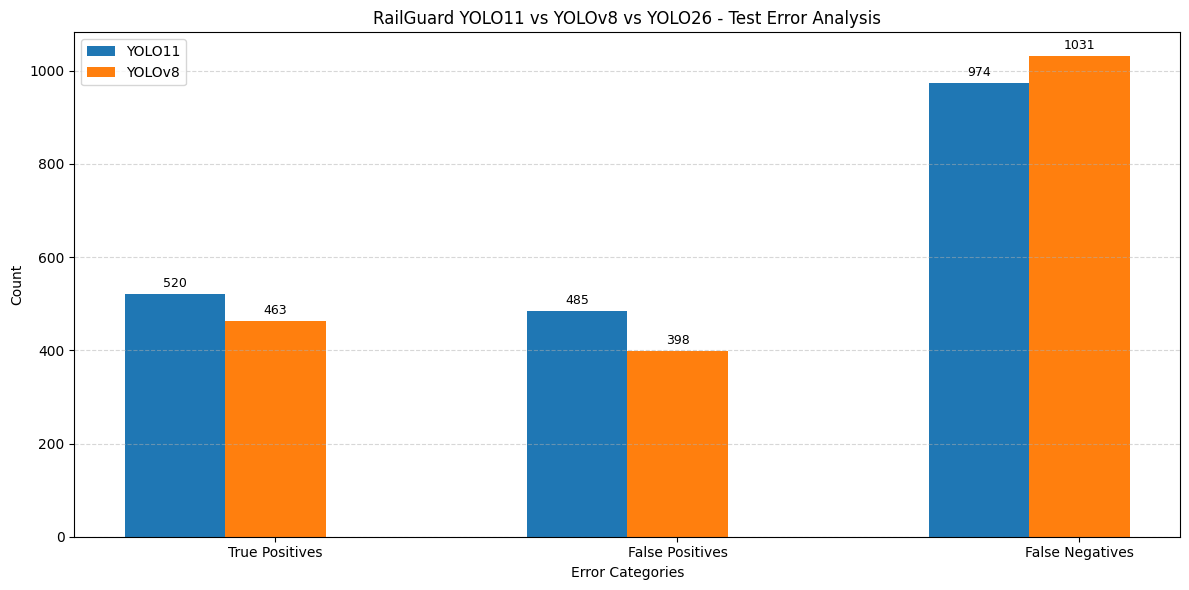

Note: YOLO26 TP/FP/FN counts are not shown because the YOLO26 run produced visual error-analysis artifacts, not individually classified FP/FN counts.


In [6]:
metric_names = [
    "True Positives",
    "False Positives",
    "False Negatives"
]

x = np.arange(len(metric_names))
width = 0.25

plt.figure(figsize=(12, 6))

for i, model in enumerate(models):
    values = error_analysis.loc[
        error_analysis["Model"] == model,
        metric_names
    ].values[0]

    # Skip models where TP/FP/FN counts were not individually produced.
    if np.isnan(values).all():
        continue

    bars = plt.bar(
        x + (i - 1) * width,
        values,
        width,
        label=model
    )

    for bar, value in zip(bars, values):
        if not np.isnan(value):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value + 15,
                str(int(value)),
                ha="center",
                fontsize=9
            )

plt.xticks(x, metric_names)
plt.ylabel("Count")
plt.xlabel("Error Categories")
plt.title("RailGuard YOLO11 vs YOLOv8 vs YOLO26 - Test Error Analysis")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print("Note: YOLO26 TP/FP/FN counts are not shown because the YOLO26 run produced visual error-analysis artifacts, not individually classified FP/FN counts.")


## Final Model Comparison

In [7]:
final_comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "mAP@50",
        "mAP@50-95"
    ],
    "YOLO11": [
        0.477,
        0.406,
        0.439,
        0.400,
        0.144
    ],
    "YOLOv8": [
        0.4316,
        0.4258,
        0.4287,
        0.3975,
        0.1372
    ],
    "YOLO26": [
        0.43436538499379523,
        0.37617135207496655,
        float(testing.loc[testing["Model"] == "YOLO26", "F1 Score"].iloc[0]),
        0.3745384121914642,
        0.13632144707501986
    ]
})

final_comparison["Better Model"] = final_comparison.apply(
    lambda row: max(
        ["YOLO11", "YOLOv8", "YOLO26"],
        key=lambda model: row[model]
    ),
    axis=1
)

display(final_comparison)


,Metric,YOLO11,YOLOv8,YOLO26,Better Model
0,Precision,0.477,0.4316,0.434365,YOLO11
1,Recall,0.406,0.4258,0.376171,YOLOv8
2,F1 Score,0.439,0.4287,0.403179,YOLO11
3,mAP@50,0.400,0.3975,0.374538,YOLO11
4,mAP@50-95,0.144,0.1372,0.136321,YOLO11


## Model Configuration Comparison

In [8]:
configuration = pd.DataFrame({
    "Parameter": [
        "Architecture",
        "Pretrained Weights",
        "Epochs",
        "Image Size",
        "Batch Size",
        "Optimizer",
        "AMP",
        "Hardware",
        "Number of Classes"
    ],
    "YOLO11": [
        "YOLO11n",
        "yolo11n.pt",
        50,
        "640 × 640",
        16,
        "AdamW",
        "Enabled",
        "NVIDIA Tesla T4",
        1
    ],
    "YOLOv8": [
        "YOLOv8n",
        "yolov8n.pt",
        50,
        "640 × 640",
        16,
        "AdamW",
        "Enabled",
        "NVIDIA Tesla T4",
        1
    ],
    "YOLO26": [
        "YOLO26n",
        "yolo26n.pt",
        50,
        "640 × 640",
        16,
        "AdamW",
        "Enabled",
        "NVIDIA Tesla T4",
        1
    ]
})

display(configuration)


,Parameter,YOLO11,YOLOv8,YOLO26
0,Architecture,YOLO11n,YOLOv8n,YOLO26n
1,Pretrained Weights,yolo11n.pt,yolov8n.pt,yolo26n.pt
2,Epochs,50,50,50
3,Image Size,640 × 640,640 × 640,640 × 640
4,Batch Size,16,16,16
5,Optimizer,AdamW,AdamW,AdamW
6,AMP,Enabled,Enabled,Enabled
7,Hardware,NVIDIA Tesla T4,NVIDIA Tesla T4,NVIDIA Tesla T4
8,Number of Classes,1,1,1
